In [1]:
from pathlib import Path
import xarray as xr
import os
import dask
import cfgrib
import matplotlib.pyplot as plt

In [2]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[3]

In [3]:
data_dir = Path(f"{repo_root}/DataGRIB")
files = sorted(list(data_dir.glob("*.grib")))

ds_tp = xr.open_mfdataset(
    files, 
    engine='cfgrib', 
    combine='nested', 
    concat_dim='time',
    backend_kwargs={'indexpath': ''}
)

data_dir = Path(f"{repo_root}/DataGRIB_v2")
files = sorted(list(data_dir.glob("*.grib")))

ds_t2m = xr.open_mfdataset(
    files, 
    engine='cfgrib', 
    combine='nested', 
    concat_dim='time',
    backend_kwargs={'indexpath': ''}
)

C:\Users\crist\AppData\Local\Temp\ipykernel_69936\3329055578.py:4: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'step' ('step',) The recommendation is to set join explicitly for this case.
  ds_tp = xr.open_mfdataset(


In [4]:
print(ds_tp); print(ds_t2m)

<xarray.Dataset> Size: 134MB
Dimensions:            (time: 3100, step: 5, latitude: 22, longitude: 49)
Coordinates:
  * time               (time) datetime64[ns] 25kB 2017-11-01 ... 2026-03-03
  * step               (step) timedelta64[ns] 40B 00:00:00 ... 1 days 00:00:00
    valid_time         (time, step) datetime64[ns] 124kB dask.array<chunksize=(31, 5), meta=np.ndarray>
  * latitude           (latitude) float64 176B 56.42 56.3 56.17 ... 53.92 53.8
  * longitude          (longitude) float64 392B 20.9 21.02 21.15 ... 26.77 26.9
    number             int64 8B 0
    surface            float64 8B 0.0
    heightAboveGround  float64 8B 2.0
Data variables:
    tp                 (time, step, latitude, longitude) float32 67MB dask.array<chunksize=(31, 5, 22, 49), meta=np.ndarray>
    t2m                (time, step, latitude, longitude) float32 67MB dask.array<chunksize=(31, 5, 22, 49), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_cent

In [5]:
ds_tp = ds_tp.sel(step="1 days")

In [7]:
ds_tp.to_netcdf(f"{repo_root}/DataGRIB/lithuania_ecmwf_2017_2026.nc")
ds_t2m.to_netcdf(f"{repo_root}/DataGRIB_v2/lithuania_ecmwf_2017_2026_v2.nc")

In [8]:
ds_tp = xr.open_dataset(f"{repo_root}/DataGRIB/lithuania_ecmwf_2017_2026.nc")
ds_t2m = xr.open_dataset(f"{repo_root}/DataGRIB_v2/lithuania_ecmwf_2017_2026_v2.nc")

In [9]:
lats = [54.68] # Vilnius
lons = [25.27]

subset_points_tp = ds_tp.sel(
    latitude=lats, 
    longitude=lons, 
    method='nearest'
)
subset_points_t2m = ds_t2m.sel(
    latitude=lats, 
    longitude=lons, 
    method='nearest'
)

In [35]:
df_tp = subset_points_tp.to_dataframe().reset_index()
df_t2m = subset_points_t2m.to_dataframe().reset_index()

In [40]:
df_tp.head()

,time,tp
0,2017-11-01,5.425942
1,2017-11-02,10.262314
2,2017-11-03,0.635839
3,2017-11-04,0.264773
4,2017-11-05,0.001663


In [39]:
df_t2m.head()

,time,t2m
0,2017-11-01,8.455841
1,2017-11-01,9.165497
2,2017-11-01,9.620300
3,2017-11-01,9.279358
4,2017-11-02,8.648529


In [38]:
df_t2m['t2m'] = df_t2m['t2m'] - 272.15
df_tp = df_tp[['time', 'tp']]
df_t2m = df_t2m[['time', 't2m']]

In [41]:
df_t2m = df_t2m.groupby('time').mean()

In [42]:
df = df_tp.join(df_t2m, on = 'time')

In [43]:
df.head()

,time,tp,t2m
0,2017-11-01,5.425942,9.130249
1,2017-11-02,10.262314,8.334129
2,2017-11-03,0.635839,7.927284
3,2017-11-04,0.264773,7.267036
4,2017-11-05,0.001663,7.160072


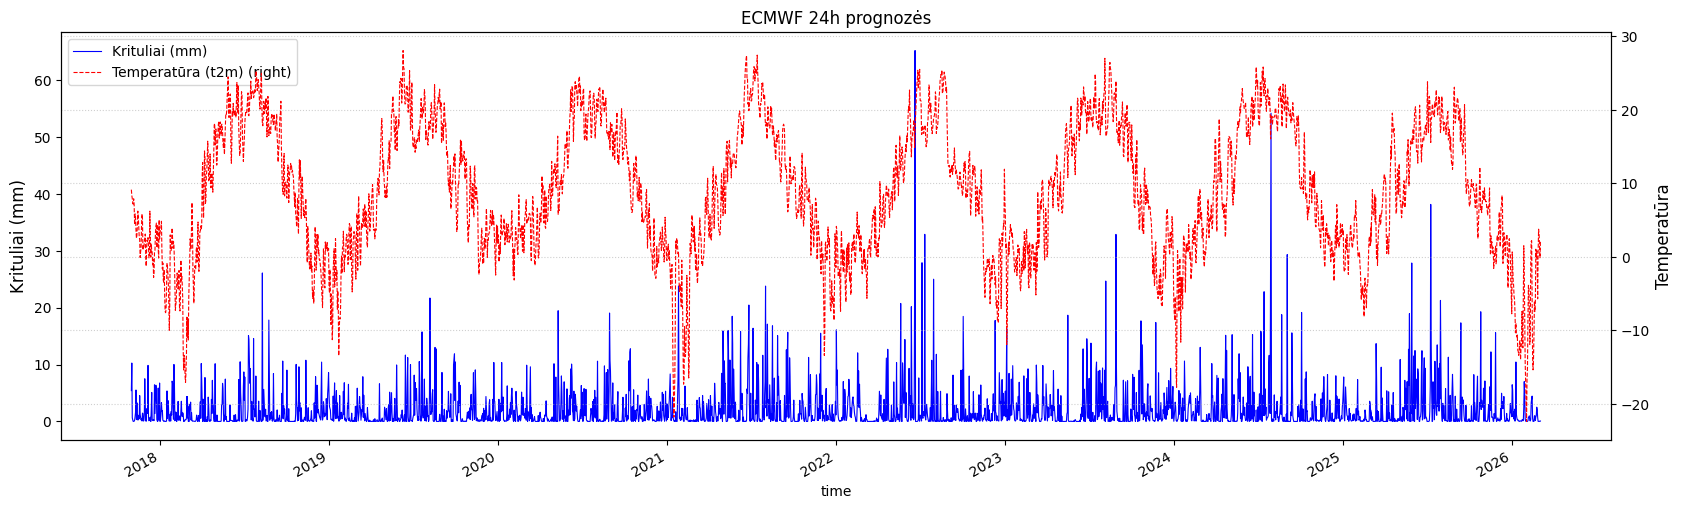

In [44]:
import matplotlib.pyplot as plt

df_time_idx = df.set_index('time')

ax = df_time_idx.tp.plot(figsize=(20, 6), linewidth=0.8, color='blue', label='Krituliai (mm)')
df_time_idx.t2m.plot(ax=ax, secondary_y=True, linewidth=0.8, linestyle='--', color='red', label='Temperatūra (t2m)')

ax.set_ylabel('Krituliai (mm)', fontsize=12)
ax.right_ax.set_ylabel('Temperatūra', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax.right_ax.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("ECMWF 24h prognozės")

plt.show()

In [45]:
df.to_csv(f"Vilnius_ecmwf_data_2017_2026.csv", index=False)